In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [2]:
def matchSummary(opt):
    for tt in opt._err.targets:
        if tt.line:
           nn=" ".join((tt.line,)+tt.tar)
           rr=tt.action.run()[tt.line][tt.tar]
        else:
           nn=tt.tar
           nn=" ".join(nn)
           rr=tt.action.run()[tt.tar]
        if(type(tt.value)==xt.match.LessThan):
            vv=tt.value.upper
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}') 
        elif(type(tt.value)==xt.match.GreaterThan):
            vv=tt.value.lower
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
        elif(hasattr(tt,'rhs')):
            vv=tt.rhs
            dd=(rr-vv)
            if(tt.ineq_sign=='>'):
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
            else:
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}')   
        else:
            vv=tt.value
            dd=(rr-vv)
            dd=np.abs(dd)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {dd<tt.tol}')

In [3]:
class nonlin_chroma(xd.Action):
    def __init__(self, line):
        self.line = line

    def run(self):
        deg = 4

        delta_values = np.arange(-3e-3, 3e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss4d(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]
        print("qx coeff:", qx_coeff)

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]
        print("qy coeff:", qy_coeff)

        return {'qx0': qx_coeff[3], 'qy0': qy_coeff[3], 
                'qx1': qx_coeff[2], 'qy1': qy_coeff[2], 
                'qx2': qx_coeff[1], 'qy2': qy_coeff[1], 
                'qx3': qx_coeff[0], 'qy3': qy_coeff[0], 
                # 'qx4': qx_coeff[-1], 'qy4': qy_coeff[-1], 
                # 'qx5': qx_coeff[2], 'qy5': qy_coeff[2], 
                # 'qx6': qx_coeff[1], 'qy6': qy_coeff[1], 
                # 'qx7': qx_coeff[0], 'qy7': qy_coeff[0], 
               }

In [4]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

# Load fitting

In [5]:
line = xt.load('sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
tt = line.get_table()

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.extend_knl_ksl(order=9, element_names=list(mba)+list(mbb)+list(qf)+list(qd))
#Creating knobs for the non-linear chromaticity fit
env['b3_mba'] = 0
env['b3_mbb'] = 0
env['b4_qd'] = 0
env['b4_qf'] = 0
env['b5_mba'] = 0
env['b5_mbb'] = 0
env['b6_qd'] = 0
env['b6_qf'] = 0
# env['b7_mba'] = 0
# env['b7_mbb'] = 0
# env['b8_qd'] = 0
# env['b8_qf'] = 0
# env['b9_mba'] = 0
# env['b9_mbb'] = 0
#Defining deferred expressions for each dipole and quadrupole
#Dipoles get b3,b5
#Quadrupoles get b4,b6

tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

# env.vars["qph_setvalue"] = 0.0
# env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl[2] = 'b3_mba'
    env[nn].knl[4] = 'b5_mba'
for nn in mbb:
    env[nn].knl[2] = 'b3_mbb'
    env[nn].knl[4] = 'b5_mbb'
for nn in qf:
    env[nn].knl[3] = 'b4_qf'
    env[nn].knl[5] = 'b6_qf'
for nn in qd:
    env[nn].knl[3] = 'b4_qd'
    env[nn].knl[5] = 'b6_qd'


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [6]:
with open("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit_v2/tune_poly_coefficients.json") as f:
      coeffs = json.load(f)

qx_coeff = np.array(coeffs["Qx_kickH"]["poly3"]["coefficients_high_to_low"])
qy_coeff = np.array(coeffs["Qy_kickV"]["poly3"]["coefficients_high_to_low"])

qx0 = qx_coeff[3] + 20
qx1 = qx_coeff[2]
qx2 = qx_coeff[1]
qx3 = qx_coeff[0]

qy0 = qy_coeff[3] + 20
qy1 = qy_coeff[2]
qy2 = qy_coeff[1]
qy3 = qy_coeff[0]

print(qx0, qx1, qx2, qx3)
print(qy0, qy1, qy2, qy3)

20.135306167062172 1.3853870500626178 -155.47561247121524 -98753.84952492008
20.178676460533286 1.3404718005055012 -567.3012263943148 59867.04451836808


# Comparison with old error model

In [7]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,       tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 11.28                             
Matching: model call n. 15 penalty = 1.8186e-05              
Optimize - end penalty:  1.81856e-05                            


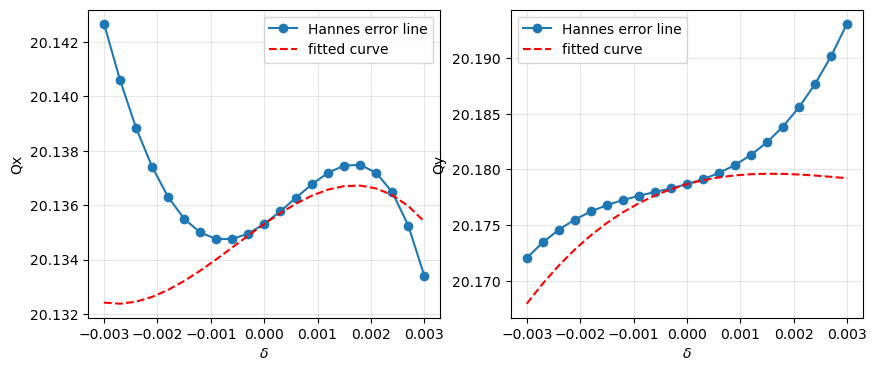

In [8]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)


axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 , 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3, 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

# Optimisation 

In [9]:
line.vars["qph_setvalue"] = qx1/qx0#0.155
line.vars["qpv_setvalue"] = qy1/qy0#0.13

act_chroma = nonlin_chroma(line)

## Optimising tune

In [10]:
#Measured tunes at delta=0
opt_tune = line.match(
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-8), 
    ],
    targets=[
        xt.TargetSet(qx=qx0, qy=qy0, tol=1e-10),
    ])

                                             
Optimize - start penalty: 0.185                             
Matching: model call n. 11 penalty = 1.9411e-10              
Optimize - end penalty:  1.94113e-10                            


In [11]:
print("Quadrupole strengths needed to recover measured tunes:")
print("kqf =", line.vars["kqf"]._get_value())
print("kqd =", line.vars["kqd"]._get_value())

Quadrupole strengths needed to recover measured tunes:
kqf = 0.011586604606965211
kqd = -0.011586525285218146


In [12]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])

qx coeff: [ 2.00467099e+03  2.43878321e+02 -1.97694727e+01  1.37452547e+00
  2.01353089e+01]
qy coeff: [-5.71519835e+03  8.02380306e+02 -8.43171999e+01  1.23557837e+00
  2.01786781e+01]
Q0:
targets  : 20.135306167062172 20.178676460533286
obtained : 1.3745254706921433 1.2355783676491778
Q1:
targets  : 1.3853870500626178 1.3404718005055012
obtained : -19.769472675388553 -84.31719989784766
Q2:
targets  : -155.47561247121524 -567.3012263943148
obtained : 243.87832112832237 802.3803062209148
Q3:
targets  : -98753.84952492008 59867.04451836808
obtained : 2004.6709879351097 -5715.198347842799


## Optimising Q1

In [13]:
opt_q1 = line.match(
    vary=[
        xt.VaryList(['b3_mba', 'b3_mbb'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-7),
    ])

                                             
Optimize - start penalty: 0.1052                            
Matching: model call n. 18 penalty = 1.6327e-08              
Optimize - end penalty:  1.6327e-08                            


In [14]:
print("Sextupole errors on main dipoles needed to recover first order chromaticity:")
print("b3_mba =", line.vars["b3_mba"]._get_value())
print("b3_mbb =", line.vars["b3_mbb"]._get_value())

Sextupole errors on main dipoles needed to recover first order chromaticity:
b3_mba = 1.242936420220578e-05
b3_mbb = -2.3751174440010102e-05


In [15]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])

qx coeff: [ 2.02962446e+03  2.42599987e+02 -1.97322869e+01  1.38531299e+00
  2.01353089e+01]
qy coeff: [-5.74988221e+03  8.06089054e+02 -8.46400225e+01  1.34024424e+00
  2.01786782e+01]
Q0:
targets  : 20.135306167062172 20.178676460533286
obtained : 1.3853129852171637 1.340244235722632
Q1:
targets  : 1.3853870500626178 1.3404718005055012
obtained : -19.73228693875383 -84.64002247012489
Q2:
targets  : -155.47561247121524 -567.3012263943148
obtained : 242.59998668929194 806.0890537906444
Q3:
targets  : -98753.84952492008 59867.04451836808
obtained : 2029.624458938564 -5749.882212505129


## Set initial guesses

In [16]:
# # This does not always work
# line.vars["b4_qd"] = 0.2510659779855401
# line.vars["b4_qf"] = -0.0648364578421977

# line.vars["b5_mba"] = -2.25810386008537
# line.vars["b5_mbb"] = 0.2656211094935512

# line.vars["b6_qd"] = -8647.346573399047
# line.vars["b6_qf"] = 1110.9478709603252

## Optimising Q2

In [17]:
opt_q2 = line.match(
    vary=[
        xt.VaryList(['b4_qd', 'b4_qf'], step=1e-7), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx2', value=qx2, tol=(np.abs(qx2) * 0.01), tag='qx2'),
        xt.Target(action=act_chroma, tar='qy2', value=qy2, tol=(np.abs(qy2) * 0.01), tag='qy2'),
    ])

qx coeff: [ 2.02962446e+03  2.42599987e+02 -1.97322869e+01  1.38531299e+00
  2.01353089e+01]
qy coeff: [-5.74988221e+03  8.06089054e+02 -8.46400225e+01  1.34024424e+00
  2.01786782e+01]
qx coeff: [ 2.02962446e+03  2.42599987e+02 -1.97322869e+01  1.38531299e+00
  2.01353089e+01]
qy coeff: [-5.74988221e+03  8.06089054e+02 -8.46400225e+01  1.34024424e+00
  2.01786782e+01]
                                             
qx coeff: [ 2.02962446e+03  2.42599987e+02 -1.97322869e+01  1.38531299e+00
  2.01353089e+01]
qy coeff: [-5.74988221e+03  8.06089054e+02 -8.46400225e+01  1.34024424e+00
  2.01786782e+01]
Optimize - start penalty: 1430                              
qx coeff: [ 2.02962446e+03  2.42599987e+02 -1.97322869e+01  1.38531299e+00
  2.01353089e+01]
qy coeff: [-5.74988221e+03  8.06089054e+02 -8.46400225e+01  1.34024424e+00
  2.01786782e+01]
qx coeff: [ 2.02615632e+03  2.42592993e+02 -1.97321675e+01  1.38531302e+00
  2.01353089e+01]
qy coeff: [-5.74990119e+03  8.06089804e+02 -8.46403676e+

In [18]:
print("Octupole errors on main quadrupoles needed to recover second order chromaticity:")
print("b4_qf =", line.vars["b4_qf"]._get_value())
print("b4_qd =", line.vars["b4_qd"]._get_value())

Octupole errors on main quadrupoles needed to recover second order chromaticity:
b4_qf = 0.01801529527846256
b4_qd = -0.0937538820732823


In [19]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])

qx coeff: [ 9.64736075e+03 -1.56975422e+02  8.14515172e+01  1.38541715e+00
  2.01353053e+01]
qy coeff: [ 1.23989189e+04 -5.67307138e+02  1.81575665e+02  1.33819670e+00
  2.01786604e+01]
Q0:
targets  : 20.135306167062172 20.178676460533286
obtained : 1.3854171538820084 1.3381966985691707
Q1:
targets  : 1.3853870500626178 1.3404718005055012
obtained : 81.45151715420667 181.57566548403742
Q2:
targets  : -155.47561247121524 -567.3012263943148
obtained : -156.975422095177 -567.3071380342979
Q3:
targets  : -98753.84952492008 59867.04451836808
obtained : 9647.360749128544 12398.918901477404


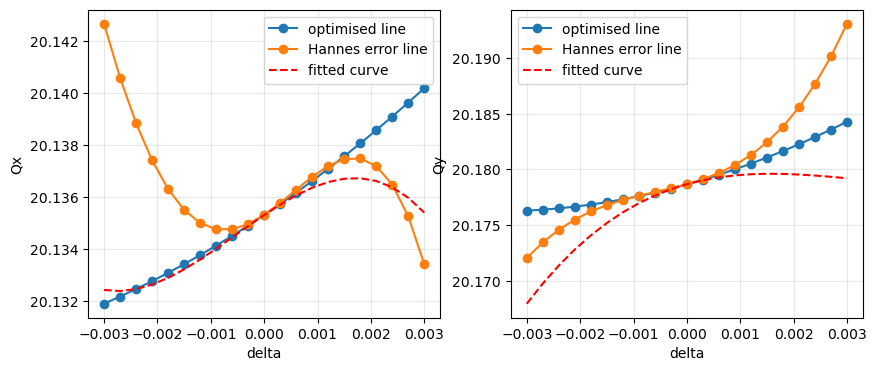

In [20]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 , 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 , 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

## Optimising Q3

In [21]:
opt_q3 = line.match(
    vary=[
        xt.VaryList(['b5_mba', 'b5_mbb'], step=1e-4), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx3', value=qx3, tol=(np.abs(qx3) * 0.0001), tag='qx3'),
        xt.Target(action=act_chroma, tar='qy3', value=qy3, tol=(np.abs(qy3) * 0.0001), tag='qy3'),
])

qx coeff: [ 9.64736075e+03 -1.56975422e+02  8.14515172e+01  1.38541715e+00
  2.01353053e+01]
qy coeff: [ 1.23989189e+04 -5.67307138e+02  1.81575665e+02  1.33819670e+00
  2.01786604e+01]
qx coeff: [ 9.64736075e+03 -1.56975422e+02  8.14515172e+01  1.38541715e+00
  2.01353053e+01]
qy coeff: [ 1.23989189e+04 -5.67307138e+02  1.81575665e+02  1.33819670e+00
  2.01786604e+01]
                                             
qx coeff: [ 9.64736075e+03 -1.56975422e+02  8.14515172e+01  1.38541715e+00
  2.01353053e+01]
qy coeff: [ 1.23989189e+04 -5.67307138e+02  1.81575665e+02  1.33819670e+00
  2.01786604e+01]
Optimize - start penalty: 1.183e+05                         
qx coeff: [ 9.64736075e+03 -1.56975422e+02  8.14515172e+01  1.38541715e+00
  2.01353053e+01]
qy coeff: [ 1.23989189e+04 -5.67307138e+02  1.81575665e+02  1.33819670e+00
  2.01786604e+01]
qx coeff: [ 9.61593192e+03 -1.52407171e+02  8.14515360e+01  1.38541714e+00
  2.01353053e+01]
qy coeff: [ 1.23945352e+04 -5.69773855e+02  1.81575665e+

In [22]:
print("Decapole errors on main dipoles needed to recover third order chromaticity:")
print("b5_mba =", line.vars["b5_mba"]._get_value())
print("b5_mbb =", line.vars["b5_mbb"]._get_value())

Decapole errors on main dipoles needed to recover third order chromaticity:
b5_mba = 0.025749491985896246
b5_mbb = 0.9674067918720741


In [23]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", qx0, qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])

qx coeff: [-9.87578970e+04  1.30335471e+04  8.14663736e+01  1.38539138e+00
  2.01353053e+01]
qy coeff: [ 5.98670408e+04 -2.06026498e+04  1.81565880e+02  1.33821369e+00
  2.01786604e+01]
Q0:
targets  : 20.135306167062172 20.178676460533286
obtained : 1.385391379723707 1.3382136872184243
Q1:
targets  : 1.3853870500626178 1.3404718005055012
obtained : 81.46637357233706 181.5658801965344
Q2:
targets  : -155.47561247121524 -567.3012263943148
obtained : 13033.547145033754 -20602.649791635053
Q3:
targets  : -98753.84952492008 59867.04451836808
obtained : -98757.89699317275 59867.04082059805


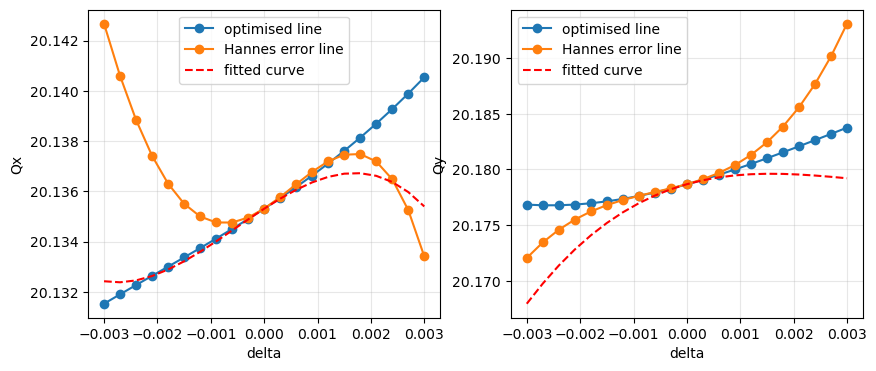

In [24]:
delta_grid = np.linspace(-3e-3, 3e-3, 21)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model, qx_model, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model, qy_model, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

axes[0].plot(delta_grid, qx0 + qx1*delta_grid + qx2*delta_grid**2 + qx3*delta_grid**3 , 'r--', label='fitted curve')
axes[1].plot(delta_grid, qy0 + qy1*delta_grid + qy2*delta_grid**2 + qy3*delta_grid**3 , 'r--', label='fitted curve')
for ax in axes:
    ax.set_xlabel("delta")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

In [25]:
line.to_json("sps_with_aperture_inj_q20_beam_sagitta4_errors_poly3.json")

# Other Q' values

In [26]:
line3 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4_errors_poly3.json")

env3 = line3.env
env3.vars["qph_setvalue"] = 0.155
env3.vars["qpv_setvalue"] = 0.13
# cavity_elements, cavity_names = line3.get_elements_of_type(xt.Cavity)
# for name in cavity_names:
#     line3[name].frequency = 200e6
#     line3[name].lag = 180
#     line3[name].voltage = 0
# line3['actcse.31632'].voltage = 3.0e6

# line3.match(
#         method="6d",
#         vary=[
#             xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
#             xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
#         ],
#         targets=[
#             xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-6, tag="tune"),
#             xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
#         ],
#     )

line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
        ],
    )

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.01033                           


KeyboardInterrupt: 

In [ ]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-3, tag="tune"),
            xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 9.53                              
Matching: model call n. 44 penalty = 4.6139e-03              
Optimize - end penalty:  0.00461393                            


In [ ]:
delta_grid3 = np.linspace(-3e-3, 3e-3, 21)
d_model3, qx_model3, qy_model3 = twiss_scan(line3, delta_grid3)

In [ ]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-3, tag="tune"),
            xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 9.53                              
Matching: model call n. 44 penalty = 4.6139e-03              
Optimize - end penalty:  0.00461393                            


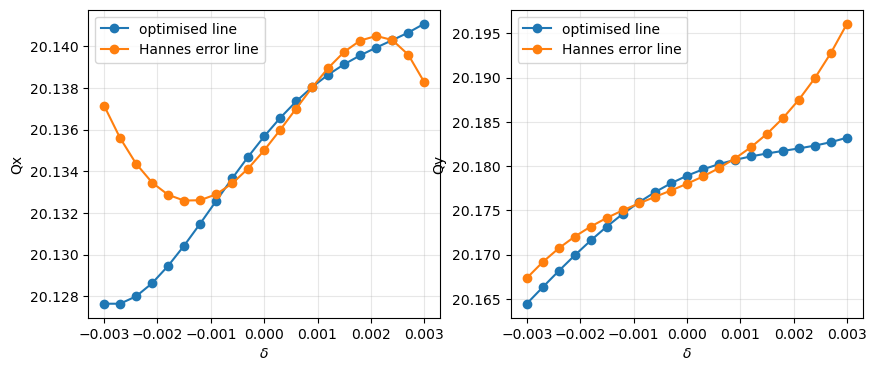

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model3, qx_model3, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model3, qy_model3, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

something is wrong with the optimisation, we can have much less tolerance

## Tests

In [ ]:
#Hannes error model for comparison step by step
line3 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env3 = line3.env

# line3.match(
#         method="6d",
#         vary=[
#             xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
#             xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
#         ],
#         targets=[
#             xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-6, tag="tune"),
#             xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
#         ],
#     )


error_variants2 = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env3.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env3.vars["qph_setvalue"] = 0.155
env3.vars["qpv_setvalue"] = 0.13

for nn in mba:
    env3[nn].knl = np.array([b1*0., b2*0., b3*1.2953616912388827e-05,   b4*0.,       b5*-2.10603563,  b6*0.])
for nn in mbb:
    env3[nn].knl = np.array([b1*0., b2*0., b3*-2.44799746e-05,  b4*0.,       b5*-2.41741244e-01,  b6*0.])
for nn in qf:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-6.56961423e-02,  b5*0.,     b6*1.13848638e+03])
for nn in qd:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*2.4785736e-01, b5*0.,     b6*-7.9631362e+03])

cavity_elements, cavity_names = line3.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line3[name].frequency = 200e6
    line3[name].lag = 180
    line3[name].voltage = 0
line3['actcse.31632'].voltage = 3.0e6

line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.155*20.13, dqy=0.13*20.18, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid3 = np.linspace(-3e-3, 3e-3, 21)
d_model3, qx_model3, qy_model3 = twiss_scan(line3, delta_grid3)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 0.2126                            
Matching: model call n. 15 penalty = 6.7681e-03              
Optimize - end penalty:  0.00676813                            


In [ ]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.155*20.13, dqy=0.13*20.18, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 9.529                             
Matching: model call n. 44 penalty = 8.5838e-03              
Optimize - end penalty:  0.00858383                            


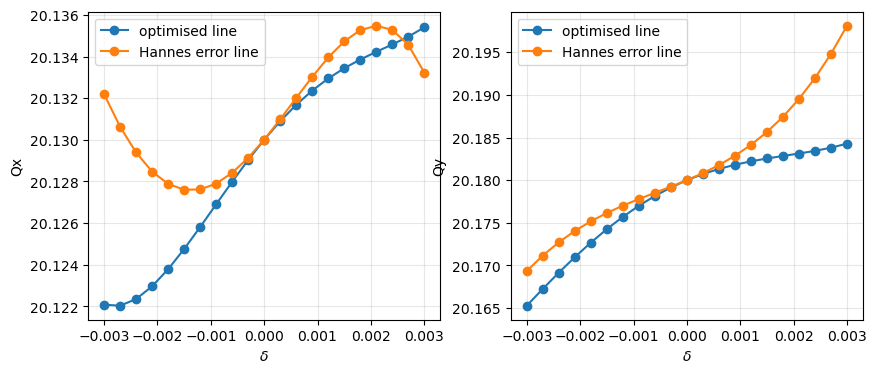

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model3, qx_model3, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model3, qy_model3, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

In [27]:
line4 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4_optimised.json")

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [ ]:
env4 = line4.env
cavity_elements, cavity_names = line4.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line4[name].frequency = 200e6
    line4[name].lag = 180
    line4[name].voltage = 0
line4['actcse.31632'].voltage = 3.0e6

env4.vars["qph_setvalue"] = 0.155
env4.vars["qpv_setvalue"] = 0.13
line4.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.155*20.13, dqy=0.13*20.18, tol=1e-2, tag="chrom"),
        ],
    )

                                             
Optimize - start penalty: 5.075                             
Matching: model call n. 176 penalty = 5.4418e-02              
Optimize - end penalty:  0.0544179                            


Could not find point within tolerance.
Matching: model call n. 177 penalty = 5.0751e+00              



RuntimeError: Could not find point within tolerance.

In [ ]:
delta_grid4 = np.linspace(-3e-3, 3e-3, 21)
d_model4, qx_model4, qy_model4 = twiss_scan(line4, delta_grid4)

KeyboardInterrupt: 

In [32]:
line3 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4_errors2.json")

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           


/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


In [34]:
env3 = line.env

In [41]:
env3.vars['qph_setvalue']._value

np.float64(0.06880387308581719)

In [38]:
tw = line3.twiss()

In [39]:
tw.qx

np.float64(20.135675738813998)

In [42]:
line3.vars['qph_setvalue']._find_dependant_targets()

[vars['qph_setvalue'],
 vars['klsfc'],
 element_refs['lsf.61205'],
 element_refs['lsf.61205'].k2,
 element_refs['lsf.60805'].k2,
 element_refs['lsf.60805'],
 element_refs['lsf.53605'].k2,
 element_refs['lsf.53605'],
 element_refs['lsf.52405'],
 element_refs['lsf.52405'].k2,
 element_refs['lsf.52005'].k2,
 element_refs['lsf.52005'],
 element_refs['lsf.51205'],
 element_refs['lsf.51205'].k2,
 element_refs['lsf.50805'].k2,
 element_refs['lsf.50805'],
 element_refs['lsf.43605'],
 element_refs['lsf.43605'].k2,
 element_refs['lsf.42405'].k2,
 element_refs['lsf.42405'],
 element_refs['lsf.42005'].k2,
 element_refs['lsf.42005'],
 element_refs['lsf.41205'].k2,
 element_refs['lsf.41205'],
 element_refs['lsf.40805'],
 element_refs['lsf.40805'].k2,
 element_refs['lsf.33605'].k2,
 element_refs['lsf.33605'],
 element_refs['lsf.33205'],
 element_refs['lsf.33205'].k2,
 vars['klsfb'],
 element_refs['lsf.62605'],
 element_refs['lsf.62605'].k2,
 element_refs['lsf.61405'],
 element_refs['lsf.61405'].k2,
 

In [43]:
line_ref = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")
tw_ref = line_ref.twiss()

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           


In [45]:
line_ref['kqd0']

-0.01158101412515668

In [46]:
line3.vars['kqf0'] = 0.01157926643000353    # set to known good starting value
line3.vars['kqd0'] = -0.01158101412515668
line3.vars['qph_setvalue'] = 0.0
line3.vars['qpv_setvalue'] = 0.0

In [47]:
env3.vars["qph_setvalue"] = 0.155
env3.vars["qpv_setvalue"] = 0.13
line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.155*20.13, dqy=0.13*20.18, tol=1e-2, tag="chrom"),
        ],
    )

                                             
Optimize - start penalty: 4.069                             
Matching: model call n. 166 penalty = 5.7804e-02              
Optimize - end penalty:  0.0578045                            


Could not find point within tolerance.
Matching: model call n. 167 penalty = 4.0689e+00              



RuntimeError: Could not find point within tolerance.

# Test manual errors


In [52]:
#Hannes error model for comparison step by step
line3 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env3 = line3.env

# line3.match(
#         method="6d",
#         vary=[
#             xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
#             xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
#         ],
#         targets=[
#             xt.TargetSet(qx=20.135,       qy=20.178,     tol=1e-6, tag="tune"),
#             xt.TargetSet(dqx=0.155*20.135, dqy=0.13*20.178, tol=1e-2, tag="chrom"),
#         ],
#     )


error_variants2 = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env3.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env3.vars["qph_setvalue"] = 0.155
env3.vars["qpv_setvalue"] = 0.13

for nn in mba:
    env3[nn].knl = np.array([b1*0., b2*0., b3*1.2953616912388827e-05,   b4*0.,       b5*-2.10603563,  b6*0.])
for nn in mbb:
    env3[nn].knl = np.array([b1*0., b2*0., b3*-2.44799746e-05,  b4*0.,       b5*-2.41741244e-01,  b6*0.])
for nn in qf:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-6.56961423e-02,  b5*0.,     b6*1.13848638e+03])
for nn in qd:
    env3[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*2.4785736e-01, b5*0.,     b6*-7.9631362e+03])

cavity_elements, cavity_names = line3.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line3[name].frequency = 200e6
    line3[name].lag = 180
    line3[name].voltage = 0
line3['actcse.31632'].voltage = 3.0e6

line3.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.5*20.13, dqy=0.5*20.18, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid3 = np.linspace(-3e-3, 3e-3, 21)
d_model3, qx_model3, qy_model3 = twiss_scan(line3, delta_grid3)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 10.05                             
Matching: model call n. 52 penalty = 4.2157e-04              
Optimize - end penalty:  0.000421567                            


In [53]:
#Hannes error model for comparison step by step
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=20.13,       qy=20.18,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=0.5*20.13, dqy=0.5*20.18, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

delta_grid2 = np.linspace(-3e-3, 3e-3, 21)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 4.929                             
Matching: model call n. 55 penalty = 3.7768e-05              
Optimize - end penalty:  3.77677e-05                            


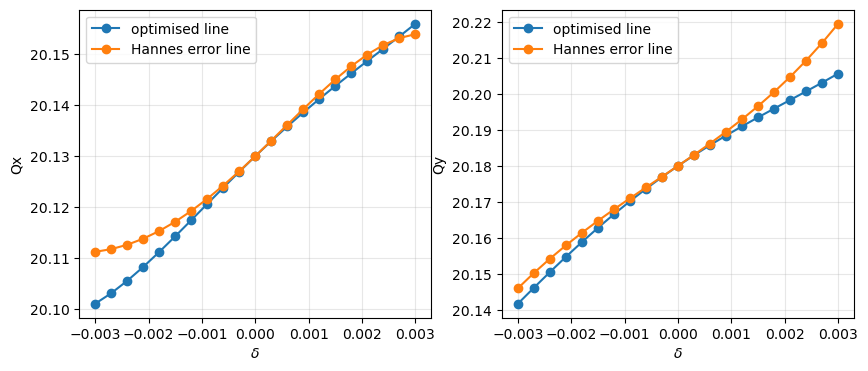

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
axes[0].plot(d_model3, qx_model3, 'o-', label='optimised line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model3, qy_model3, 'o-', label='optimised line')
axes[1].set_ylabel("Qy")

axes[0].plot(d_model2, qx_model2, 'o-', label='Hannes error line')
axes[0].set_ylabel("Qx")
axes[1].plot(d_model2, qy_model2, 'o-', label='Hannes error line')
axes[1].set_ylabel("Qy")

for ax in axes:
    ax.set_xlabel(r"$\delta$")
    ax.grid(True, alpha=0.3)

axes[0].legend()
axes[1].legend()

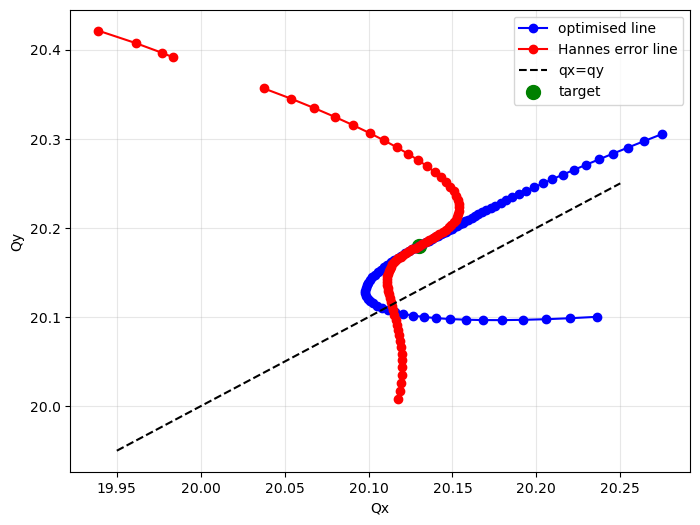

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))

# grid = np.linspace(-8e-3, 8e-3, 81)
# d_model, qx_model, qy_model = twiss_scan(line3, grid)
# d_model2, qx_model2, qy_model2 = twiss_scan(line2, grid)

ax.plot(qx_model, qy_model, 'o-', label='optimised line', color='blue')
ax.plot(qx_model2, qy_model2, 'o-', label='Hannes error line', color='red')
ax.set_xlabel("Qx")
ax.set_ylabel("Qy")
ax.grid(True, alpha=0.3)
ax.plot(np.linspace(19.95, 20.25, 30), np.linspace(19.95, 20.25, 30), 'k--', label='qx=qy')
ax.scatter([20.13], [20.18], color='green', marker='o', s=100, label='target')
ax.legend()
# ax.set_aspect('equal')